In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatwCDM
import camb
import sys
import os
import time

# Add the source directory to the Python path to use local development version
sys.path.insert(0, os.path.abspath('/datadec/cppm/boccard/excursion_set_functions/src'))

# Import from reference repository
from excursion_set_functions import analytical as f_an_py
from excursion_set_functions import integration
from excursion_set_functions import numerical
from excursion_set_functions.utilities import delta_NL_underdensity


# Import photo-z module from local development source
from excursion_set_functions.python.photo_z import compute_vsf_eulerian_with_photoz

import scipy.special as sp
from matplotlib import ticker

# Enable LaTeX for text rendering with better compatibility
plt.rcParams['text.usetex'] = True
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 14

/tmp/ipykernel_2030328/2754095526.py:144: RuntimeWarning: invalid value encountered in divide
  ratio[valid] = VSF_ph[valid] / VSF_iso[valid]


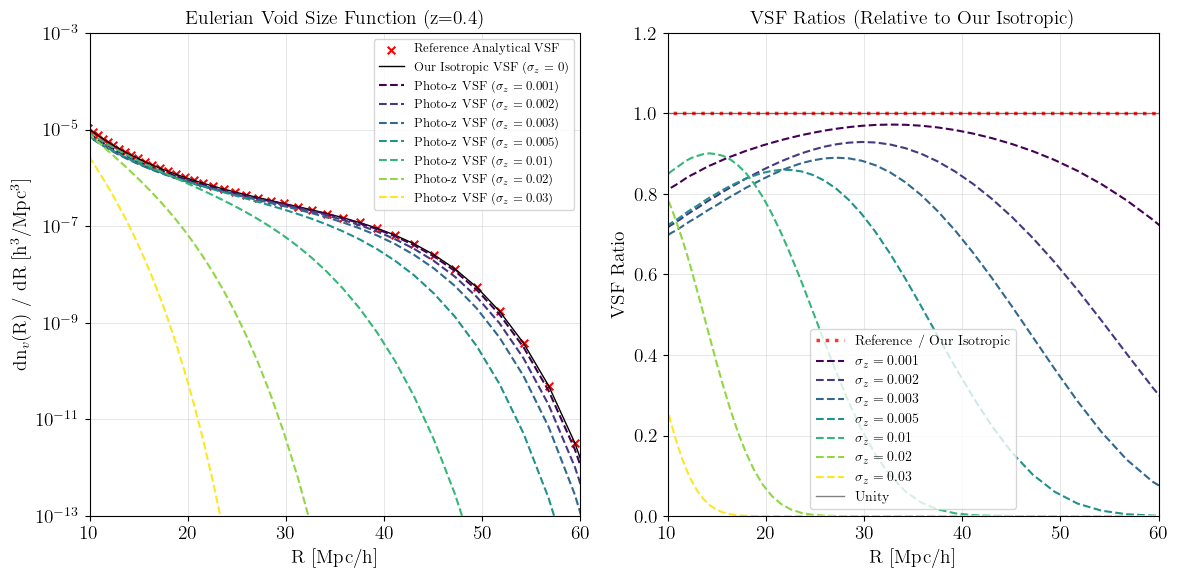

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ax = axes[0]

# ===== COSMOLOGY AND POWER SPECTRUM =====
omega_m = 0.3
w = -1.0
redshift_min, redshift_max = 0.3, 0.5
cosmo = FlatwCDM(H0=71, Om0=omega_m, w0=w, Ob0=0.044)
z_mean = (redshift_min + redshift_max) / 2.0
a1, a2 = 0.0, 0.1
b1, b2 = 1, -0.7
gamma = 1
bias = 2
delta_v_lin = -0.8

# Compute power spectrum
pars = camb.CAMBparams()
pars.set_cosmology(
    H0=cosmo.H0.value, 
    ombh2=cosmo.Ob0 * (cosmo.H0.value / 100)**2, 
    omch2=(cosmo.Om0 - cosmo.Ob0) * (cosmo.H0.value / 100)**2
)
pars.InitPower.set_params(ns=0.965)
redshift = np.linspace(redshift_min, redshift_max, 10)[::-1]
pars.set_matter_power(redshifts=redshift, kmax=2.0)
results = camb.get_results(pars)
k, z_arr, pk = results.get_matter_power_spectrum(minkh=1.e-4, maxkh=2, npoints=1000)
Pk = np.mean(pk.T, axis=1)

# Reference computation
R = np.logspace(2, 0, 101)
s = integration.sigma2_TopHat(Pk, k, R)
s22 = integration.sigma2_2_TopHat_numdiff(Pk, k, R)
dsdR = integration.dSdR_TopHat(Pk, k, R)
DW = s22 / dsdR**2

alpha = a1 * abs(delta_v_lin) + a2
beta = b1 * abs(delta_v_lin) + b2

B = alpha * (1.0 + (beta / s)**gamma)
dB_ds = -alpha * beta**gamma * gamma * s**(-gamma - 1.0)

f_appr_R = f_an_py.f_S_MB_approx(s, DW, B, dB_ds) * np.abs(dsdR)
VSF_approx_L = 3.0 / (4.0 * np.pi * R**3) * f_appr_R

delta_v_NL = delta_NL_underdensity(delta_v_lin)
expansion_factor = (1.0 + delta_v_NL)**(-1.0/3.0)
R_E = R * expansion_factor
VSF_approx_E = VSF_approx_L / expansion_factor

ax.scatter(R_E, VSF_approx_E, label='Reference Analytical VSF', 
        color='red', marker='x', s=30)



power_spectrum_cache = {}
R_E_iso, VSF_iso, s_iso = compute_vsf_eulerian_with_photoz(
    a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
    redshift_min, redshift_max, sigma_z=0.0,
    f_S_MB_approx_func=f_an_py.f_S_MB_approx,
    delta_NL_func=delta_NL_underdensity,
    power_spectrum_cache=power_spectrum_cache,
    verbose=True
)

ax.plot(R_E_iso, VSF_iso, label=r'Our Isotropic VSF ($\sigma_z=0$)', 
        color='black', linewidth=1)

# Photo-z cases
sigma_array = [0.001, 0.002, 0.003, 0.005, 0.01, 0.02, 0.03]
colors = plt.cm.viridis(np.linspace(0, 1, len(sigma_array)))

for idx, sigma_z in enumerate(sigma_array):
    
    R_E_ph, VSF_ph, s_ph = compute_vsf_eulerian_with_photoz(
        a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
        redshift_min, redshift_max, sigma_z=sigma_z,
        f_S_MB_approx_func=f_an_py.f_S_MB_approx,
        delta_NL_func=delta_NL_underdensity,
        power_spectrum_cache=power_spectrum_cache,
        verbose=True
    )
    
    label = fr'Photo-z VSF ($\sigma_z = {sigma_z}$)'
    ax.plot(R_E_ph, VSF_ph, label=label, linestyle='--', color=colors[idx])

# Format left plot
ax.set_yscale('log')
ax.set_xlabel(r'R [Mpc/h]', fontsize=14)
ax.set_ylabel(r'dn$_v$(R) / dR [h$^3$/Mpc$^3$]', fontsize=14)
ax.set_xlim(10, 60)
ax.set_ylim(1e-13, 1e-3)
ax.grid(visible=True, which='major', axis='both', 
        linestyle='-', linewidth=0.7, alpha=0.3)
ax.legend(fontsize=9, loc='best')
ax.set_title(f'Eulerian Void Size Function (z={z_mean:.1f})', fontsize=14)

# ===== RATIO PLOT =====
ax = axes[1]

# Interpolate to common R grid for fair comparison
from scipy.interpolate import interp1d

# Find common R range
R_common = np. linspace(
    max(R_E. min(), R_E_iso.min()),
    min(R_E.max(), R_E_iso.max()),
    200
)

# Interpolate both VSFs to common grid
VSF_ref_interp = interp1d(R_E, VSF_approx_E, kind='cubic', 
                            bounds_error=False, fill_value=np.nan)
VSF_iso_interp = interp1d(R_E_iso, VSF_iso, kind='cubic',
                            bounds_error=False, fill_value=np.nan)

VSF_ref_common = VSF_ref_interp(R_common)
VSF_iso_common = VSF_iso_interp(R_common)

# Compute ratio
valid_ref = ~np.isnan(VSF_ref_common) & ~np.isnan(VSF_iso_common) & (VSF_iso_common > 0)
ratio_ref = np.full_like(R_common, np.nan)
ratio_ref[valid_ref] = VSF_ref_common[valid_ref] / VSF_iso_common[valid_ref]

# Plot reference/isotropic ratio
ax.plot(R_common, ratio_ref, 
        label=r'Reference / Our Isotropic', 
        color='red', linestyle=':', linewidth=2.5, alpha=0.8)

# Plot photo-z ratios
for idx, sigma_z in enumerate(sigma_array):
    R_E_ph, VSF_ph, s_ph = compute_vsf_eulerian_with_photoz(
        a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
        redshift_min, redshift_max, sigma_z=sigma_z,
        f_S_MB_approx_func=f_an_py.f_S_MB_approx,
        delta_NL_func=delta_NL_underdensity,
        power_spectrum_cache=power_spectrum_cache,
        verbose=False
    )
    
    valid = ~np.isnan(VSF_ph) & ~np.isnan(VSF_iso)
    if np.any(valid):
        ratio = np.full_like(VSF_ph, np.nan)
        ratio[valid] = VSF_ph[valid] / VSF_iso[valid]
        ax.plot(R_E_ph, ratio, label=fr'$\sigma_z={sigma_z}$', 
                linestyle='--', color=colors[idx])

ax.set_xlabel(r'R [Mpc/h]', fontsize=14)
ax.set_ylabel(r'VSF Ratio', fontsize=14)
ax.axhline(1.0, color='black', linestyle='-', linewidth=1.0, alpha=0.5, label='Unity')
ax.set_xlim(10, 60)
ax.set_ylim(0.0, 1.2)
ax.grid(visible=True, which='major', axis='both', 
        linestyle='-', linewidth=0.7, alpha=0.3)
ax.legend(fontsize=10, loc='best')
ax.set_title(r'VSF Ratios (Relative to Our Isotropic)', fontsize=14)

plt.tight_layout()
plt.show()


/tmp/ipykernel_2030328/26554800.py:145: RuntimeWarning: invalid value encountered in divide
  ratio[valid] = VSF_ph[valid] / VSF_iso[valid]


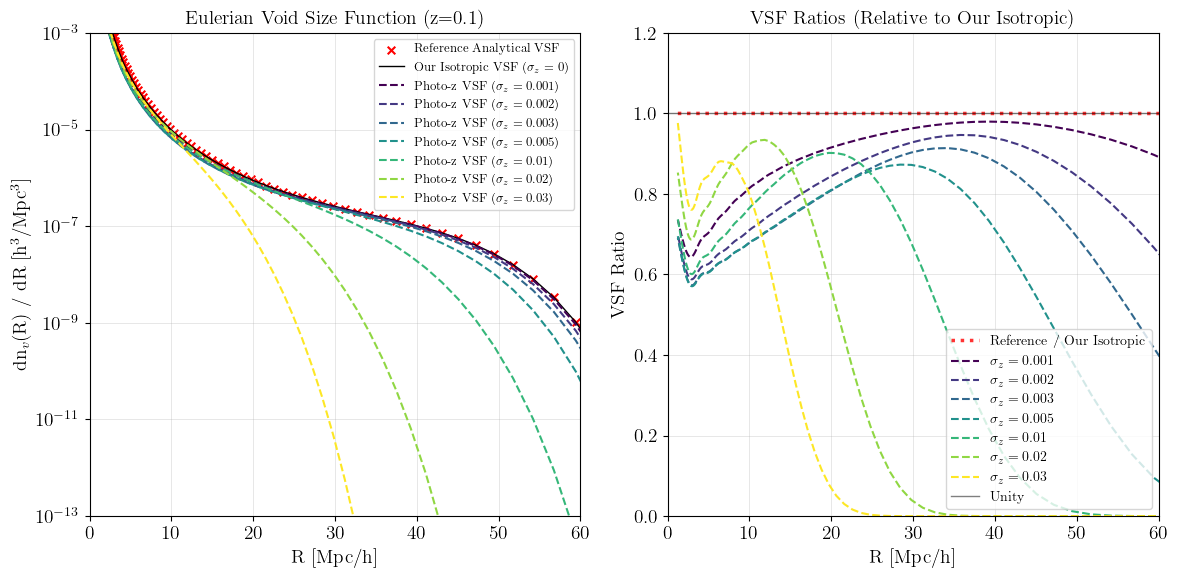

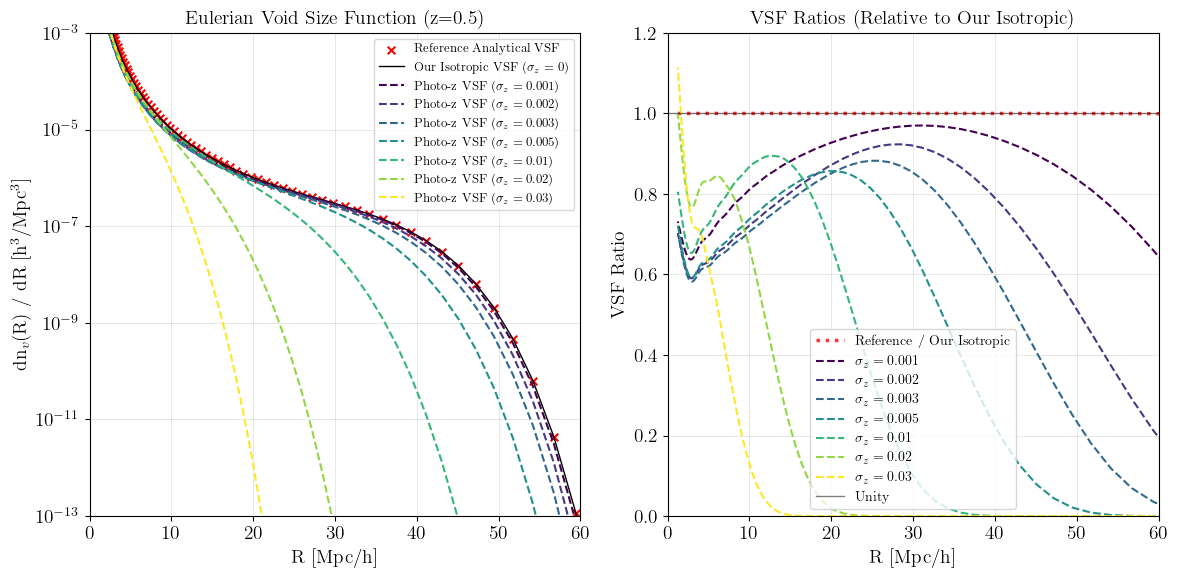

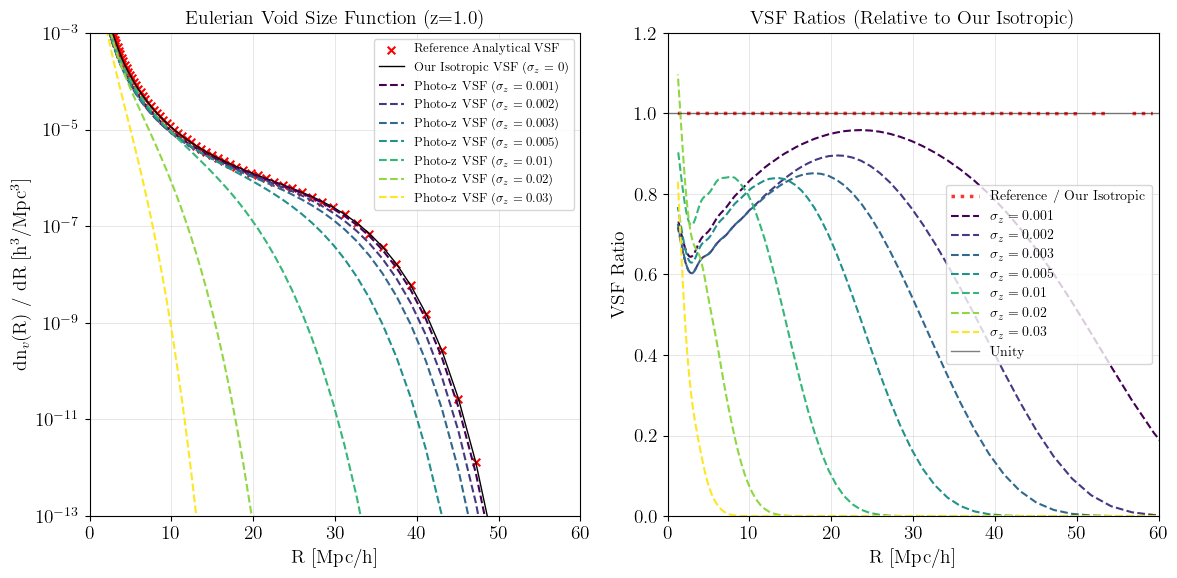

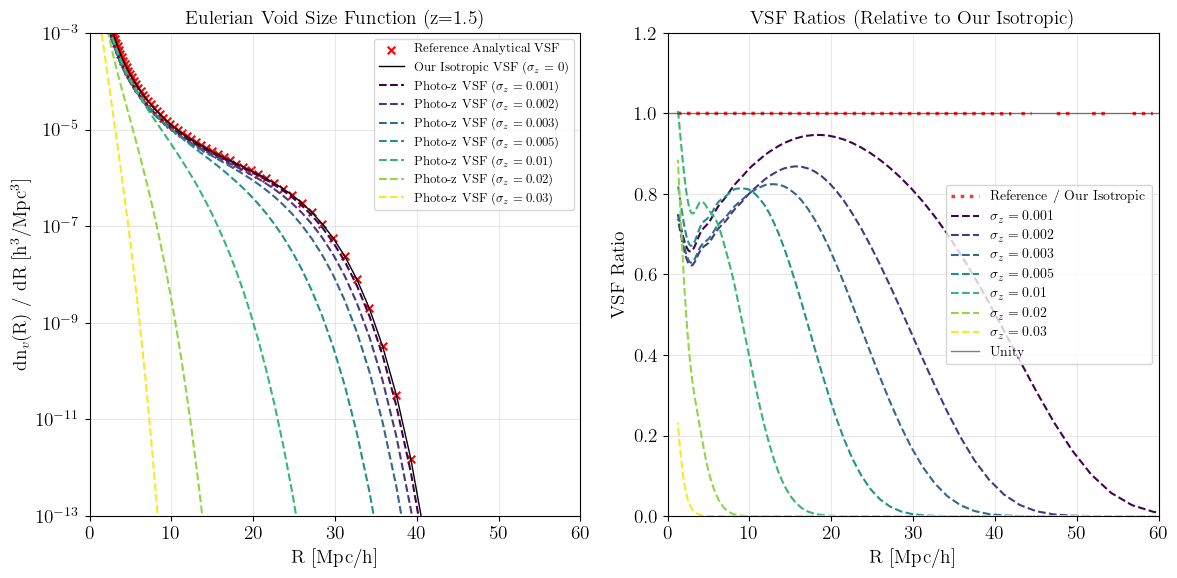

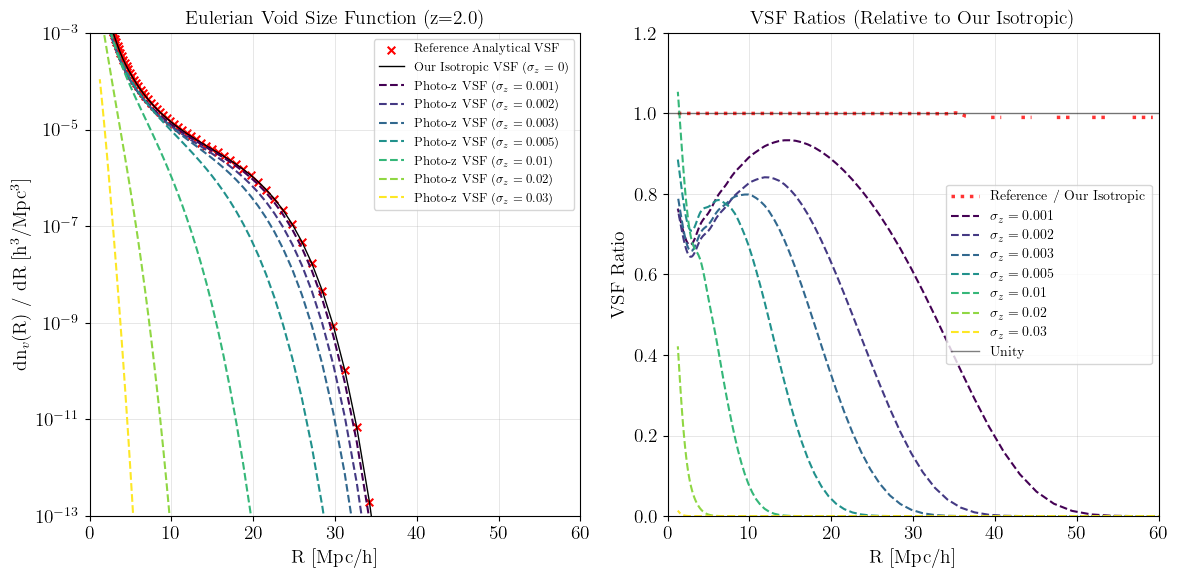

In [4]:
z_mean_list = [0.1, 0.5, 1., 1.5, 2.0]
for z_mean in z_mean_list:
    
    redshift_min = z_mean - 0.1
    redshift_max = z_mean + 0.1

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    ax = axes[0]

    # ===== COSMOLOGY AND POWER SPECTRUM =====
    omega_m = 0.3
    w = -1.0
    cosmo = FlatwCDM(H0=71, Om0=omega_m, w0=w, Ob0=0.044)
    bias = 2

    # Compute power spectrum
    pars = camb.CAMBparams()
    pars.set_cosmology(
        H0=cosmo.H0.value, 
        ombh2=cosmo.Ob0 * (cosmo.H0.value / 100)**2, 
        omch2=(cosmo.Om0 - cosmo.Ob0) * (cosmo.H0.value / 100)**2
    )
    pars.InitPower.set_params(ns=0.965)
    redshift = np.linspace(redshift_min, redshift_max, 10)[::-1]
    pars.set_matter_power(redshifts=redshift, kmax=2.0)
    results = camb.get_results(pars)
    k, z_arr, pk = results.get_matter_power_spectrum(minkh=1.e-4, maxkh=2, npoints=1000)
    Pk = np.mean(pk.T, axis=1)

    # Reference computation
    R = np.logspace(2, 0, 101)
    s = integration.sigma2_TopHat(Pk, k, R)
    s22 = integration.sigma2_2_TopHat_numdiff(Pk, k, R)
    dsdR = integration.dSdR_TopHat(Pk, k, R)
    DW = s22 / dsdR**2

    delta_v_lin = -0.8
    alpha = a1 * abs(delta_v_lin) + a2
    beta = b1 * abs(delta_v_lin) + b2

    B = alpha * (1.0 + (beta / s)**gamma)
    dB_ds = -alpha * beta**gamma * gamma * s**(-gamma - 1.0)

    f_appr_R = f_an_py.f_S_MB_approx(s, DW, B, dB_ds) * np.abs(dsdR)
    VSF_approx_L = 3.0 / (4.0 * np.pi * R**3) * f_appr_R

    delta_v_NL = delta_NL_underdensity(delta_v_lin)
    expansion_factor = (1.0 + delta_v_NL)**(-1.0/3.0)
    R_E = R * expansion_factor
    VSF_approx_E = VSF_approx_L / expansion_factor

    ax.scatter(R_E, VSF_approx_E, label='Reference Analytical VSF', 
            color='red', marker='x', s=30)



    power_spectrum_cache = {}
    R_E_iso, VSF_iso, s_iso = compute_vsf_eulerian_with_photoz(
        a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
        redshift_min, redshift_max, sigma_z=0.0,
        f_S_MB_approx_func=f_an_py.f_S_MB_approx,
        delta_NL_func=delta_NL_underdensity,
        power_spectrum_cache=power_spectrum_cache,
        verbose=True
    )

    ax.plot(R_E_iso, VSF_iso, label=r'Our Isotropic VSF ($\sigma_z=0$)', 
            color='black', linewidth=1)

    # Photo-z cases
    sigma_array = [0.001, 0.002, 0.003, 0.005, 0.01, 0.02, 0.03]
    colors = plt.cm.viridis(np.linspace(0, 1, len(sigma_array)))

    for idx, sigma_z in enumerate(sigma_array):
        
        R_E_ph, VSF_ph, s_ph = compute_vsf_eulerian_with_photoz(
            a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
            redshift_min, redshift_max, sigma_z=sigma_z,
            f_S_MB_approx_func=f_an_py.f_S_MB_approx,
            delta_NL_func=delta_NL_underdensity,
            power_spectrum_cache=power_spectrum_cache,
            verbose=True
        )
        
        label = fr'Photo-z VSF ($\sigma_z = {sigma_z}$)'
        ax.plot(R_E_ph, VSF_ph, label=label, linestyle='--', color=colors[idx])

    # Format left plot
    ax.set_yscale('log')
    ax.set_xlabel(r'R [Mpc/h]', fontsize=14)
    ax.set_ylabel(r'dn$_v$(R) / dR [h$^3$/Mpc$^3$]', fontsize=14)
    ax.set_xlim(0, 60)
    ax.set_ylim(1e-13, 1e-3)
    ax.grid(visible=True, which='major', axis='both', 
            linestyle='-', linewidth=0.7, alpha=0.3)
    ax.legend(fontsize=9, loc='best')
    ax.set_title(f'Eulerian Void Size Function (z={z_mean:.1f})', fontsize=14)

    # ===== RATIO PLOT =====
    ax = axes[1]

    # Interpolate to common R grid for fair comparison
    from scipy.interpolate import interp1d

    # Find common R range
    R_common = np. linspace(
        max(R_E. min(), R_E_iso.min()),
        min(R_E.max(), R_E_iso.max()),
        200
    )

    # Interpolate both VSFs to common grid
    VSF_ref_interp = interp1d(R_E, VSF_approx_E, kind='cubic', 
                                bounds_error=False, fill_value=np.nan)
    VSF_iso_interp = interp1d(R_E_iso, VSF_iso, kind='cubic',
                                bounds_error=False, fill_value=np.nan)

    VSF_ref_common = VSF_ref_interp(R_common)
    VSF_iso_common = VSF_iso_interp(R_common)

    # Compute ratio
    valid_ref = ~np.isnan(VSF_ref_common) & ~np.isnan(VSF_iso_common) & (VSF_iso_common > 0)
    ratio_ref = np.full_like(R_common, np.nan)
    ratio_ref[valid_ref] = VSF_ref_common[valid_ref] / VSF_iso_common[valid_ref]

    # Plot reference/isotropic ratio
    ax.plot(R_common, ratio_ref, 
            label=r'Reference / Our Isotropic', 
            color='red', linestyle=':', linewidth=2.5, alpha=0.8)

    # Plot photo-z ratios
    for idx, sigma_z in enumerate(sigma_array):
        R_E_ph, VSF_ph, s_ph = compute_vsf_eulerian_with_photoz(
            a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
            redshift_min, redshift_max, sigma_z=sigma_z,
            f_S_MB_approx_func=f_an_py.f_S_MB_approx,
            delta_NL_func=delta_NL_underdensity,
            power_spectrum_cache=power_spectrum_cache,
            verbose=False
        )
        
        valid = ~np.isnan(VSF_ph) & ~np.isnan(VSF_iso)
        if np.any(valid):
            ratio = np.full_like(VSF_ph, np.nan)
            ratio[valid] = VSF_ph[valid] / VSF_iso[valid]
            ax.plot(R_E_ph, ratio, label=fr'$\sigma_z={sigma_z}$', 
                    linestyle='--', color=colors[idx])

    ax.set_xlabel(r'R [Mpc/h]', fontsize=14)
    ax.set_ylabel(r'VSF Ratio', fontsize=14)
    ax.axhline(1.0, color='black', linestyle='-', linewidth=1.0, alpha=0.5, label='Unity')
    ax.set_xlim(0, 60)
    ax.set_ylim(0.0, 1.2)
    ax.grid(visible=True, which='major', axis='both', 
            linestyle='-', linewidth=0.7, alpha=0.3)
    ax.legend(fontsize=10, loc='best')
    ax.set_title(r'VSF Ratios (Relative to Our Isotropic)', fontsize=14)

    plt.tight_layout()
    plt.show()


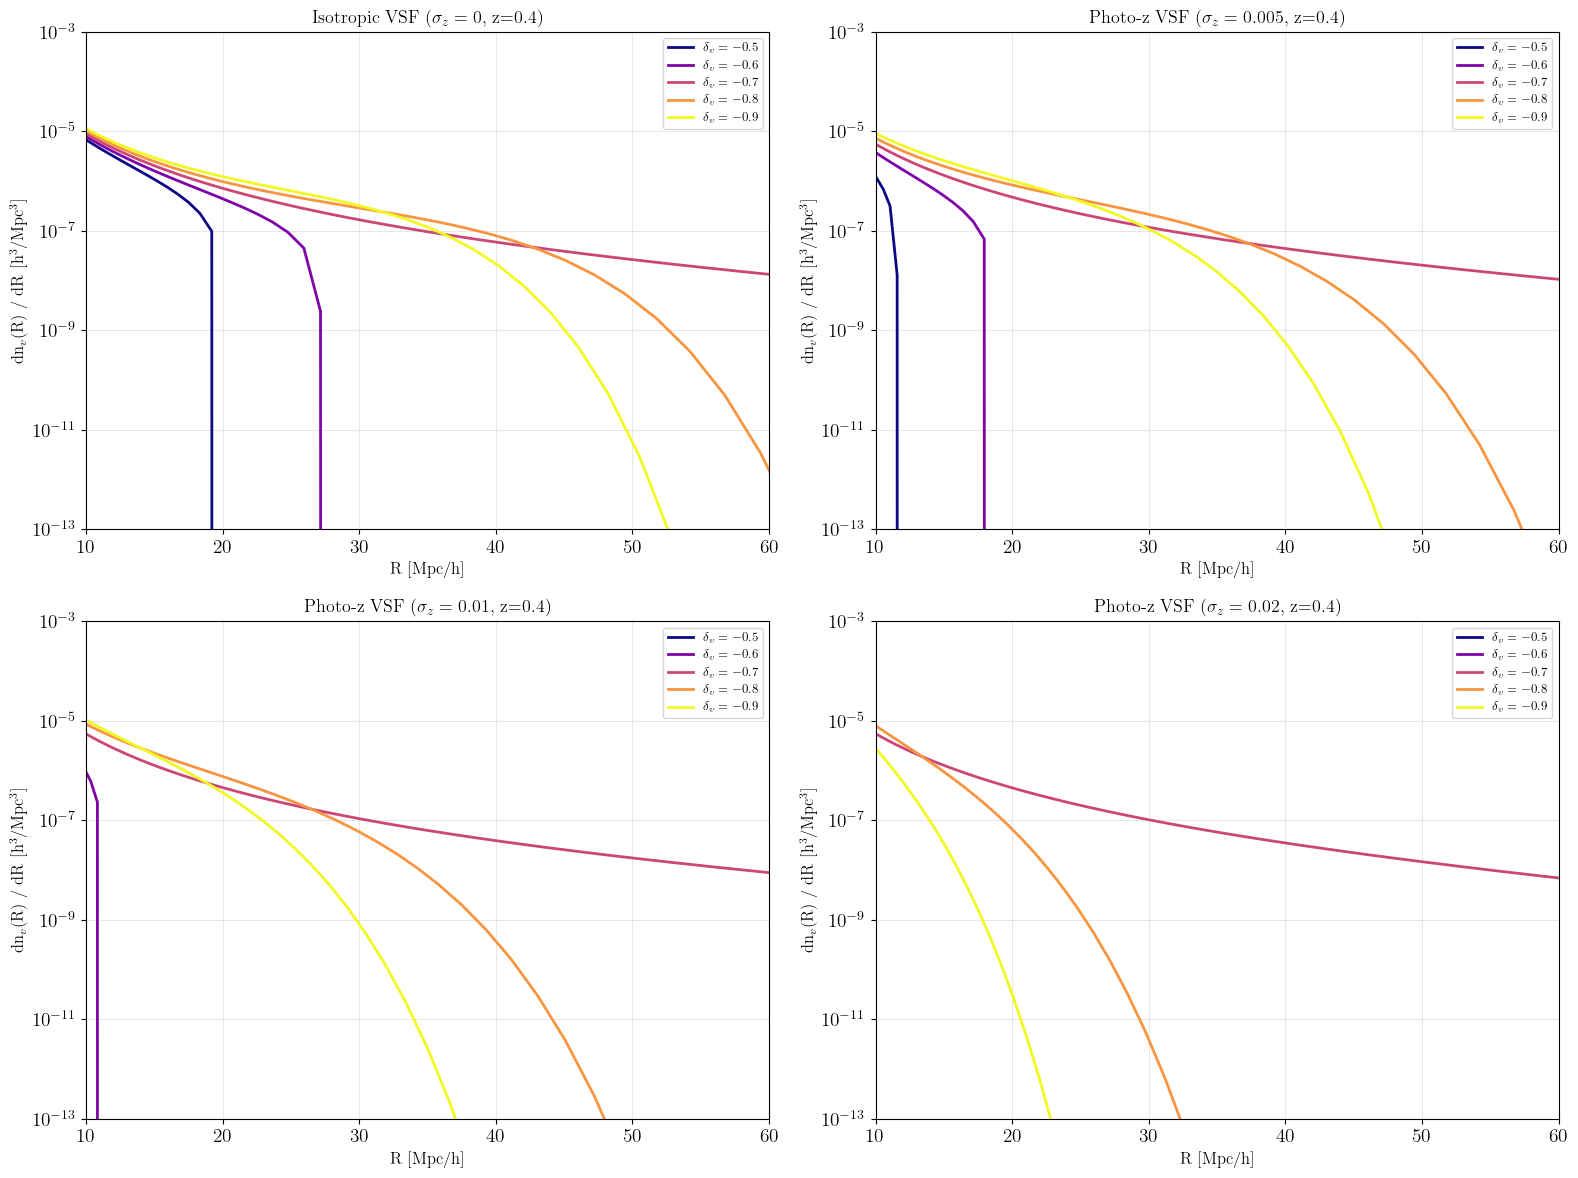

In [5]:
# Create 2x2 subplot grid for different sigma_z values
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Configuration
redshift_min, redshift_max = 0.3, 0.5
z_mean = (redshift_min + redshift_max) / 2.0
omega_m = 0.3
w = -1.0
cosmo = FlatwCDM(H0=71, Om0=omega_m, w0=w, Ob0=0.044)
bias = 2

# Compute power spectrum
pars = camb.CAMBparams()
pars.set_cosmology(
    H0=cosmo.H0.value, 
    ombh2=cosmo.Ob0 * (cosmo.H0.value / 100)**2, 
    omch2=(cosmo.Om0 - cosmo.Ob0) * (cosmo.H0.value / 100)**2
)
pars.InitPower.set_params(ns=0.965)
redshift = np.linspace(redshift_min, redshift_max, 10)[::-1]
pars.set_matter_power(redshifts=redshift, kmax=2.0)
results = camb.get_results(pars)
k, z_arr, pk = results.get_matter_power_spectrum(minkh=1.e-4, maxkh=2, npoints=1000)
Pk = np.mean(pk.T, axis=1)

# Different sigma_z values for each subplot
sigma_z_values = [0.0, 0.005, 0.01, 0.02]

# Different delta_v_lin values to vary
delta_v_array = [-0.5, -0.6, -0.7, -0.8, -0.9]
colors_delta = plt.cm.plasma(np.linspace(0, 1, len(delta_v_array)))

for subplot_idx, sigma_z in enumerate(sigma_z_values):
    ax = axes[subplot_idx]
    power_spectrum_cache = {}
    
    for idx, delta_v_lin in enumerate(delta_v_array):
        
        R_E_ph, VSF_ph, s_ph = compute_vsf_eulerian_with_photoz(
            a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
            redshift_min, redshift_max, sigma_z=sigma_z,
            f_S_MB_approx_func=f_an_py.f_S_MB_approx,
            delta_NL_func=delta_NL_underdensity,
            power_spectrum_cache=power_spectrum_cache,
            verbose=False
        )
        
        label = fr'$\delta_v = {delta_v_lin}$'
        ax.plot(R_E_ph, VSF_ph, label=label, linestyle='-', 
                color=colors_delta[idx], linewidth=2)
    
    # Format subplot
    ax.set_yscale('log')
    ax.set_xlabel(r'R [Mpc/h]', fontsize=12)
    ax.set_ylabel(r'dn$_v$(R) / dR [h$^3$/Mpc$^3$]', fontsize=12)
    ax.set_xlim(10, 60)
    ax.set_ylim(1e-13, 1e-3)
    ax.grid(visible=True, which='major', axis='both', 
            linestyle='-', linewidth=0.7, alpha=0.3)
    ax.legend(fontsize=9, loc='best')
    
    # Title with sigma_z value
    if sigma_z == 0.0:
        ax.set_title(fr'Isotropic VSF ($\sigma_z = 0$, z={z_mean:.1f})', fontsize=13)
    else:
        ax.set_title(fr'Photo-z VSF ($\sigma_z = {sigma_z}$, z={z_mean:.1f})', fontsize=13)

plt.tight_layout()
plt.show()


alpha array: [0.01 0.05 0.1  0.15 0.2  0.5  1.  ]
a1_array: [-0.5        -0.33333333 -0.16666667  0.          0.16666667  0.33333333
  0.5       ]
a2_array: [0.41       0.31666667 0.23333333 0.15       0.06666667 0.23333333
 0.6       ]


/tmp/ipykernel_2030328/1147124885.py:100: RuntimeWarning: divide by zero encountered in divide
  ratio[valid] = VSF_ph[valid] / VSF_iso[valid]
/tmp/ipykernel_2030328/1147124885.py:100: RuntimeWarning: invalid value encountered in divide
  ratio[valid] = VSF_ph[valid] / VSF_iso[valid]


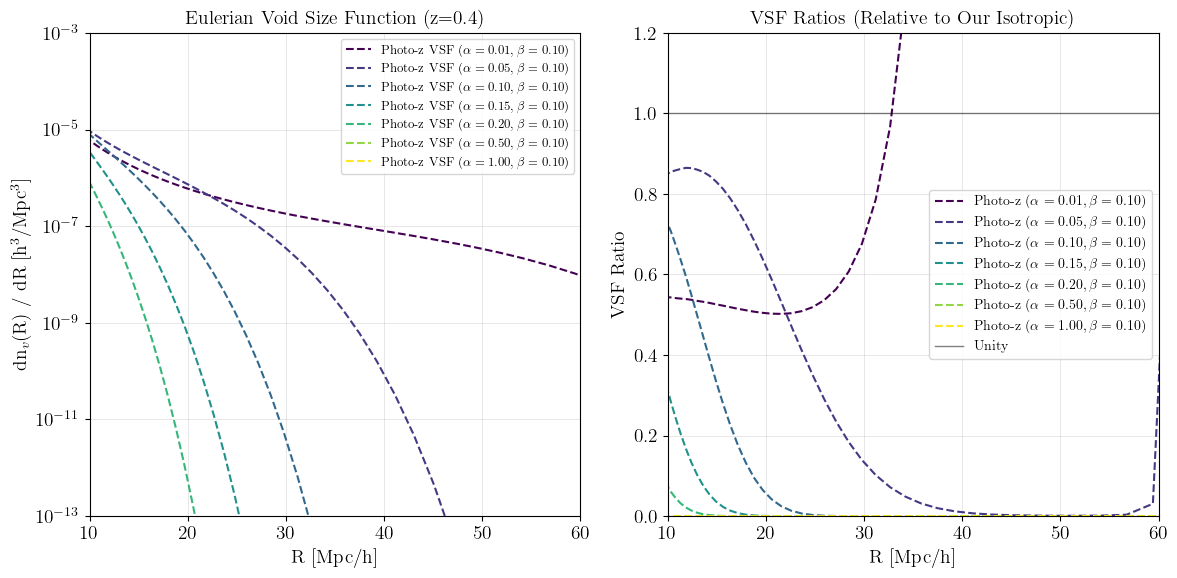

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ax = axes[0]

# ===== COSMOLOGY AND POWER SPECTRUM =====
omega_m = 0.3
w = -1.0
redshift_min, redshift_max = 0.3, 0.5
cosmo = FlatwCDM(H0=71, Om0=omega_m, w0=w, Ob0=0.044)
z_mean = (redshift_min + redshift_max) / 2.0
gamma = 1
bias = 2
delta_v_lin = -0.8


power_spectrum_cache = {}


# Photo-z cases
sigma_z = 0.02
alpha_array = np.array([0.01, 0.05, 0.1, 0.15, 0.2, 0.5, 1])
a1_array = np.linspace(-0.5, 0.5, len(alpha_array))
a2_array = alpha_array - a1_array * abs(delta_v_lin)
b1, b2 = 1, -0.7
beta = b1 * abs(delta_v_lin) + b2
gamma = 1

print("alpha array:", alpha_array)
print("a1_array:", a1_array)
print("a2_array:", a2_array)


colors = plt.cm.viridis(np.linspace(0, 1, len(a1_array)))

for idx, (a1_val, a2_val, alpha_val) in enumerate(zip(a1_array, a2_array, alpha_array)):
    
    R_E_ph, VSF_ph, s_ph = compute_vsf_eulerian_with_photoz(
        a1_val, a2_val, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
        redshift_min, redshift_max, sigma_z=sigma_z,
        f_S_MB_approx_func=f_an_py.f_S_MB_approx,
        delta_NL_func=delta_NL_underdensity,
        power_spectrum_cache=power_spectrum_cache,
        verbose=True
    )
    
    label = fr'Photo-z VSF ($\alpha = {alpha_val:.2f}, \beta={beta:.2f}$)'
    ax.plot(R_E_ph, VSF_ph, label=label, linestyle='--', color=colors[idx])

# Format left plot
ax.set_yscale('log')
ax.set_xlabel(r'R [Mpc/h]', fontsize=14)
ax.set_ylabel(r'dn$_v$(R) / dR [h$^3$/Mpc$^3$]', fontsize=14)
ax.set_xlim(10, 60)
ax.set_ylim(1e-13, 1e-3)
ax.grid(visible=True, which='major', axis='both', 
        linestyle='-', linewidth=0.7, alpha=0.3)
ax.legend(fontsize=9, loc='best')
ax.set_title(f'Eulerian Void Size Function (z={z_mean:.1f})', fontsize=14)

# ===== RATIO PLOT =====
ax = axes[1]

# Interpolate to common R grid for fair comparison
from scipy.interpolate import interp1d

# Find common R range
R_common = np. linspace(
    max(R_E. min(), R_E_iso.min()),
    min(R_E.max(), R_E_iso.max()),
    200
)

# Interpolate both VSFs to common grid
VSF_ref_interp = interp1d(R_E, VSF_approx_E, kind='cubic', 
                            bounds_error=False, fill_value=np.nan)
VSF_iso_interp = interp1d(R_E_iso, VSF_iso, kind='cubic',
                            bounds_error=False, fill_value=np.nan)

VSF_ref_common = VSF_ref_interp(R_common)
VSF_iso_common = VSF_iso_interp(R_common)

# Compute ratio
valid_ref = ~np.isnan(VSF_ref_common) & ~np.isnan(VSF_iso_common) & (VSF_iso_common > 0)
ratio_ref = np.full_like(R_common, np.nan)
ratio_ref[valid_ref] = VSF_ref_common[valid_ref] / VSF_iso_common[valid_ref]

# Plot photo-z ratios
for idx, (a1_val, a2_val, alpha_val) in enumerate(zip(a1_array, a2_array, alpha_array)):
    R_E_ph, VSF_ph, s_ph = compute_vsf_eulerian_with_photoz(
        a1_val, a2_val, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
        redshift_min, redshift_max, sigma_z=sigma_z,
        f_S_MB_approx_func=f_an_py.f_S_MB_approx,
        delta_NL_func=delta_NL_underdensity,
        power_spectrum_cache=power_spectrum_cache,
        verbose=False
    )
    
    valid = ~np.isnan(VSF_ph) & ~np.isnan(VSF_iso)
    if np.any(valid):
        ratio = np.full_like(VSF_ph, np.nan)
        ratio[valid] = VSF_ph[valid] / VSF_iso[valid]
        ax.plot(R_E_ph, ratio, label=fr'Photo-z ($\alpha = {alpha_val:.2f}, \beta={beta:.2f}$)', 
                linestyle='--', color=colors[idx])

ax.set_xlabel(r'R [Mpc/h]', fontsize=14)
ax.set_ylabel(r'VSF Ratio', fontsize=14)
ax.axhline(1.0, color='black', linestyle='-', linewidth=1.0, alpha=0.5, label='Unity')
ax.set_xlim(10, 60)
ax.set_ylim(0.0, 1.2)
ax.grid(visible=True, which='major', axis='both', 
        linestyle='-', linewidth=0.7, alpha=0.3)
ax.legend(fontsize=10, loc='best')
ax.set_title(r'VSF Ratios (Relative to Our Isotropic)', fontsize=14)

plt.tight_layout()
plt.show()


alpha array: [0.01 0.05 0.1  0.15 0.2  0.5  1.  ]
a1_array: [-0.5        -0.33333333 -0.16666667  0.          0.16666667  0.33333333
  0.5       ]
a2_array: [0.41       0.31666667 0.23333333 0.15       0.06666667 0.23333333
 0.6       ]


/tmp/ipykernel_2030328/1335229545.py:101: RuntimeWarning: divide by zero encountered in divide
  ratio[valid] = VSF_ph[valid] / VSF_iso[valid]
/tmp/ipykernel_2030328/1335229545.py:101: RuntimeWarning: invalid value encountered in divide
  ratio[valid] = VSF_ph[valid] / VSF_iso[valid]


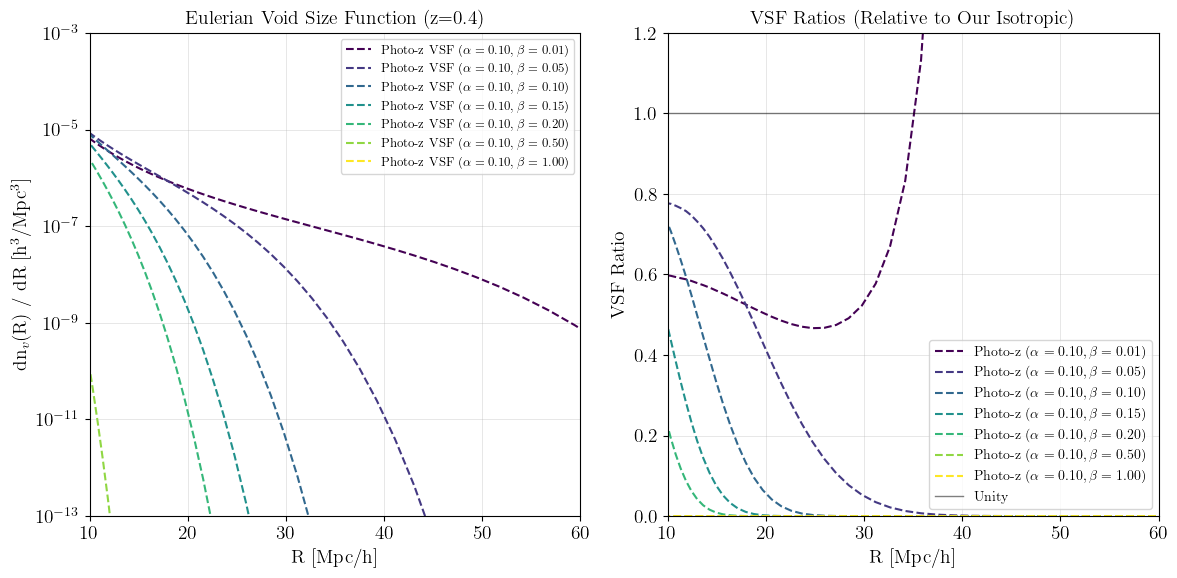

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ax = axes[0]

# ===== COSMOLOGY AND POWER SPECTRUM =====
omega_m = 0.3
w = -1.0
redshift_min, redshift_max = 0.3, 0.5
cosmo = FlatwCDM(H0=71, Om0=omega_m, w0=w, Ob0=0.044)
z_mean = (redshift_min + redshift_max) / 2.0
gamma = 1
bias = 2
delta_v_lin = -0.8


power_spectrum_cache = {}


# Photo-z cases
sigma_z = 0.02
beta_array = np.array([0.01, 0.05, 0.1, 0.15, 0.2, 0.5, 1])
b1_array = np.linspace(-0.5, 0.5, len(beta_array))
b2_array = beta_array - b1_array * abs(delta_v_lin)
a1, a2 = 0.5, -0.3
alpha = a1 * abs(delta_v_lin) + a2
gamma = 1

print("alpha array:", alpha_array)
print("a1_array:", a1_array)
print("a2_array:", a2_array)


colors = plt.cm.viridis(np.linspace(0, 1, len(b1_array)))

for idx, (b1_val, b2_val, beta_val) in enumerate(zip(b1_array, b2_array, beta_array)):
    
    R_E_ph, VSF_ph, s_ph = compute_vsf_eulerian_with_photoz(
        a1, a2, b1_val, b2_val, gamma, delta_v_lin, omega_m, w, bias,
        redshift_min, redshift_max, sigma_z=sigma_z,
        f_S_MB_approx_func=f_an_py.f_S_MB_approx,
        delta_NL_func=delta_NL_underdensity,
        power_spectrum_cache=power_spectrum_cache,
        verbose=True
    )
    
    label = fr'Photo-z VSF ($\alpha = {alpha:.2f}, \beta={beta_val:.2f}$)'
    ax.plot(R_E_ph, VSF_ph, label=label, linestyle='--', color=colors[idx])

# Format left plot
ax.set_yscale('log')
ax.set_xlabel(r'R [Mpc/h]', fontsize=14)
ax.set_ylabel(r'dn$_v$(R) / dR [h$^3$/Mpc$^3$]', fontsize=14)
ax.set_xlim(10, 60)
ax.set_ylim(1e-13, 1e-3)
ax.grid(visible=True, which='major', axis='both', 
        linestyle='-', linewidth=0.7, alpha=0.3)
ax.legend(fontsize=9, loc='best')
ax.set_title(f'Eulerian Void Size Function (z={z_mean:.1f})', fontsize=14)

# ===== RATIO PLOT =====
ax = axes[1]

# Interpolate to common R grid for fair comparison
from scipy.interpolate import interp1d

# Find common R range
R_common = np. linspace(
    max(R_E. min(), R_E_iso.min()),
    min(R_E.max(), R_E_iso.max()),
    200
)

# Interpolate both VSFs to common grid
VSF_ref_interp = interp1d(R_E, VSF_approx_E, kind='cubic', 
                            bounds_error=False, fill_value=np.nan)
VSF_iso_interp = interp1d(R_E_iso, VSF_iso, kind='cubic',
                            bounds_error=False, fill_value=np.nan)

VSF_ref_common = VSF_ref_interp(R_common)
VSF_iso_common = VSF_iso_interp(R_common)

# Compute ratio
valid_ref = ~np.isnan(VSF_ref_common) & ~np.isnan(VSF_iso_common) & (VSF_iso_common > 0)
ratio_ref = np.full_like(R_common, np.nan)
ratio_ref[valid_ref] = VSF_ref_common[valid_ref] / VSF_iso_common[valid_ref]


# Plot photo-z ratios
for idx, (b1_val, b2_val, beta_val) in enumerate(zip(b1_array, b2_array, beta_array)):
    R_E_ph, VSF_ph, s_ph = compute_vsf_eulerian_with_photoz(
        a1, a2, b1_val, b2_val, gamma, delta_v_lin, omega_m, w, bias,
        redshift_min, redshift_max, sigma_z=sigma_z,
        f_S_MB_approx_func=f_an_py.f_S_MB_approx,
        delta_NL_func=delta_NL_underdensity,
        power_spectrum_cache=power_spectrum_cache,
        verbose=False
    )
    
    valid = ~np.isnan(VSF_ph) & ~np.isnan(VSF_iso)
    if np.any(valid):
        ratio = np.full_like(VSF_ph, np.nan)
        ratio[valid] = VSF_ph[valid] / VSF_iso[valid]
        ax.plot(R_E_ph, ratio, label=fr'Photo-z ($\alpha = {alpha:.2f}, \beta={beta_val:.2f}$)', 
                linestyle='--', color=colors[idx])

ax.set_xlabel(r'R [Mpc/h]', fontsize=14)
ax.set_ylabel(r'VSF Ratio', fontsize=14)
ax.axhline(1.0, color='black', linestyle='-', linewidth=1.0, alpha=0.5, label='Unity')
ax.set_xlim(10, 60)
ax.set_ylim(0.0, 1.2)
ax.grid(visible=True, which='major', axis='both', 
        linestyle='-', linewidth=0.7, alpha=0.3)
ax.legend(fontsize=10, loc='best')
ax.set_title(r'VSF Ratios (Relative to Our Isotropic)', fontsize=14)

plt.tight_layout()
plt.show()


a1: -0.5, a2: 0.53, b1: -0.5, b2: 0.54, gamma: 1, delta_v_lin: -0.8, omega_m: 0.3, w: -1.0, bias: 2, redshift_min: 0.8, redshift_max: 1.0, sigma_z: 0.02, sigma_z: 0.02, f_S_MB_approx_func: f_an_py.f_S_MB_approx, delta_NL_func: delta_NL_underdensity
a1 : -0.5, a2 : 0.53, b1 : -0.5, b2 : 0.54, gamma : 1, delta_v_lin : -0.8, omega_m : 0.3, w : -1.0, bias : 2, redshift_min : 0.8, redshift_max : 1.0, sigma_z : 0.02


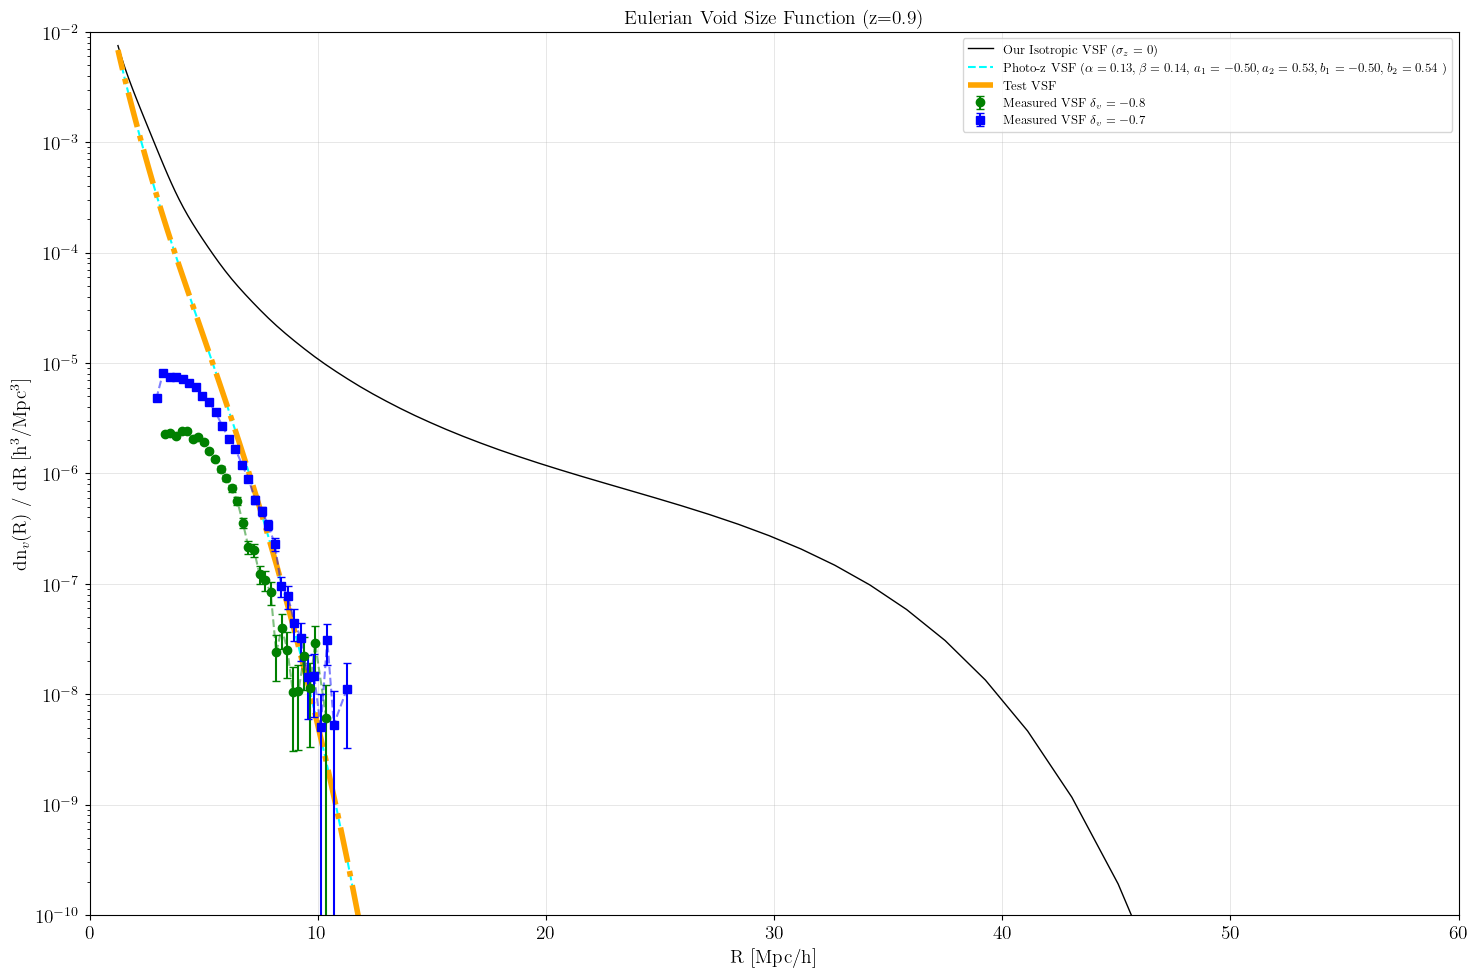

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# ===== COSMOLOGY AND POWER SPECTRUM =====
omega_m = 0.3
w = -1.0
redshift_min, redshift_max = 0.8, 1.
cosmo = FlatwCDM(H0=71, Om0=omega_m, w0=w, Ob0=0.044)
z_mean = (redshift_min + redshift_max) / 2.0
gamma = 1
bias = 2
delta_v_lin = -0.8


power_spectrum_cache = {}
R_E_iso, VSF_iso, s_iso = compute_vsf_eulerian_with_photoz(
    a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
    redshift_min, redshift_max, sigma_z=0.0,
    f_S_MB_approx_func=f_an_py.f_S_MB_approx,
    delta_NL_func=delta_NL_underdensity,
    power_spectrum_cache=power_spectrum_cache,
    verbose=True
)

ax.plot(R_E_iso, VSF_iso, label=r'Our Isotropic VSF ($\sigma_z=0$)', 
        color='black', linewidth=1)


# Photo-z cases
sigma_z = 0.02
alpha_array = np.array([0.13])
a1_array = np.linspace(-0.5, 0.5, len(alpha_array))
a2_array = alpha_array - a1_array * abs(delta_v_lin)
beta_array = np.array([0.14])
b1_array = np.linspace(-0.5, 0.5, len(beta_array))
b2_array = beta_array - b1_array * abs(delta_v_lin)
gamma = 1


colors = plt.cm.cool(np.linspace(0, 1, len(b1_array)*len(a1_array)))

for idx, (b1_val, b2_val, beta_val) in enumerate(zip(b1_array, b2_array, beta_array)):
    
    for jdx, (a1_val, a2_val, alpha_val) in enumerate(zip(a1_array, a2_array, alpha_array)):
    
        R_E_ph, VSF_ph, s_ph = compute_vsf_eulerian_with_photoz(
            a1_val, a2_val, b1_val, b2_val, gamma, delta_v_lin, omega_m, w, bias,
            redshift_min, redshift_max, sigma_z=sigma_z,
            f_S_MB_approx_func=f_an_py.f_S_MB_approx,
            delta_NL_func=delta_NL_underdensity,
            power_spectrum_cache=power_spectrum_cache,
            verbose=True)
        
        print(f"a1: {a1_val}, a2: {a2_val}, b1: {b1_val}, b2: {b2_val}, gamma: {gamma}, delta_v_lin: {delta_v_lin}, omega_m: {omega_m}, w: {w}, bias: {bias}, redshift_min: {redshift_min}, redshift_max: {redshift_max}, sigma_z: {sigma_z}, sigma_z: {sigma_z}, f_S_MB_approx_func: f_an_py.f_S_MB_approx, delta_NL_func: delta_NL_underdensity")
        
        label = fr'Photo-z VSF ($\alpha = {alpha_val:.2f}, \beta={beta_val:.2f}$, $a_1={a1_val:.2f}, a_2={a2_val:.2f}, b_1={b1_val:.2f}, b_2={b2_val:.2f}$ )'
        ax.plot(R_E_ph, VSF_ph, label=label, linestyle='--', color=colors[idx*len(a1_array)+jdx])
        
        
a1_test = -0.5; a2_test = 0.53; b1_test = -0.5; b2_test = 0.54; gamma_test = 1
R_E_test, VSF_test, s_test = compute_vsf_eulerian_with_photoz(
    a1_test, a2_test, b1_test, b2_test, gamma_test, delta_v_lin=delta_v_lin, omega_m=omega_m, w=w, bias=1,
    redshift_min=redshift_min, redshift_max=redshift_max, sigma_z=sigma_z,
    f_S_MB_approx_func=f_an_py.f_S_MB_approx,
    delta_NL_func=delta_NL_underdensity, power_spectrum_cache=power_spectrum_cache,verbose=True)

print(fr'a1 : {a1_test}, a2 : {a2_test}, b1 : {b1_test}, b2 : {b2_test}, gamma : {gamma_test}, delta_v_lin : {delta_v_lin}, omega_m : {omega_m}, w : {w}, bias : {bias}, redshift_min : {redshift_min}, redshift_max : {redshift_max}, sigma_z : {sigma_z}')

ax.plot(R_E_test, VSF_test, label=f'Test VSF', linestyle='-.', color='orange', linewidth=4)
    

vsfR02 = np.array([10.37240532,  9.88466738,  9.64079841,  9.39692944,  9.15306047,
   8.9091915,  8.66532253,  8.42145356,  8.17758459,  7.93371562,
   7.68984665,  7.44597768,  7.20210872,  6.95823975,  6.71437078,
   6.47050181,  6.22663284,  5.98276387,  5.7388949,  5.49502593,
   5.25115696,  5.00728799,  4.76341902,  4.51955005,
   4.27568108,  4.03181211,  3.78794314,  3.54407418,  3.30020521])
vsf_values02 = np.array([6.08775792e-09, 2.90074772e-08, 1.13167284e-08, 2.20609318e-08,
  1.07442034e-08, 1.04579409e-08, 2.54291962e-08, 3.95416639e-08,
  2.39978837e-08, 8.38160191e-08, 1.08319542e-07, 1.22365125e-07,
  2.02898486e-07, 2.16447789e-07, 3.58611826e-07, 5.65851051e-07,
  7.38214417e-07, 9.16474245e-07, 1.09805417e-06, 1.35778103e-06,
  1.59647696e-06, 1.91908251e-06, 2.15831079e-06, 2.04250826e-06,
  2.43670206e-06, 2.41367256e-06, 2.17652690e-06, 2.32553297e-06,
  2.27591850e-06])
vsf_error02 = np.array([6.08775792e-09, 1.29725382e-08, 8.00213539e-09, 1.10304659e-08,
  7.59729910e-09, 7.39488096e-09, 1.13722822e-08, 1.39800893e-08,
  1.07321799e-08, 1.97556252e-08, 2.21106340e-08, 2.31248349e-08,
  2.92858738e-08, 2.97313903e-08, 3.75927340e-08, 4.63563243e-08,
  5.19405851e-08, 5.67283316e-08, 6.08155959e-08, 6.61741984e-08,
  7.01451705e-08, 7.50995019e-08, 7.76793052e-08, 7.36068883e-08,
  7.81974903e-08, 7.55750193e-08, 6.95621014e-08, 6.95507151e-08,
  6.63953667e-08])

vsfR03 = np.array([11.28019087, 10.70445237, 10.41658311, 10.12871386,  9.84084461,  9.55297535,
  9.2651061,   8.97723685,  8.68936759,  8.40149834,  8.11362909,  7.82575983,
  7.53789058,  7.25002133,  6.96215207,  6.67428282,  6.38641357,  6.09854431,
  5.81067506,  5.52280581,  5.23493655,  4.9470673,   4.65919805,  4.37132879,
  4.08345954,  3.79559029,  3.50772103,  3.21985178,  2.93198253])
                  
vsf_values03 = np.array([1.12227381e-08, 5.32496598e-09, 3.10905867e-08, 5.03856291e-09,
  1.46860841e-08, 1.42564795e-08, 3.22627082e-08, 4.46575679e-08,
  7.78059946e-08, 9.61251356e-08, 2.30060675e-07, 3.42579658e-07,
  4.57469393e-07, 5.77047615e-07, 9.00469976e-07, 1.20521246e-06,
  1.68060284e-06, 2.07204542e-06, 2.71421700e-06, 3.57153992e-06,
  4.45046991e-06, 5.04983931e-06, 6.04928522e-06, 6.56056386e-06,
  7.24575674e-06, 7.42978843e-06, 7.55728175e-06, 8.20243957e-06,
  4.84084318e-06])
vsf_error03 = np.array([7.93567420e-09, 5.32496598e-09, 1.26926789e-08, 5.03856291e-09,
  8.47901463e-09, 8.23098231e-09, 1.21941575e-08, 1.41219629e-08,
  1.83390488e-08, 2.00434763e-08, 3.04722808e-08, 3.65191142e-08,
  4.14173328e-08, 4.56196195e-08, 5.58447772e-08, 6.32572491e-08,
  7.30696889e-08, 7.92846145e-08, 8.85751241e-08, 9.90566947e-08,
  1.07655157e-07, 1.11477926e-07, 1.18408753e-07, 1.19441022e-07,
  1.21319942e-07, 1.18441549e-07, 1.14834272e-07, 1.14621385e-07,
  8.40267154e-08])


ax.errorbar(vsfR02, vsf_values02, yerr=vsf_error02, label=fr'Measured VSF $\delta_v = -0.8$', 
        color='green', marker='o', linestyle='None', capsize=3, markersize=6)
ax.plot(vsfR02, vsf_values02, color='green', linestyle='--', alpha=0.5)

ax.errorbar(vsfR03, vsf_values03, yerr=vsf_error03, label=fr'Measured VSF $\delta_v = -0.7$',
        color='blue', marker='s', linestyle='None', capsize=3, markersize=6)
ax.plot(vsfR03, vsf_values03, color='blue', linestyle='--', alpha=0.5)


ax.set_yscale('log')
ax.set_xlabel(r'R [Mpc/h]', fontsize=14)
ax.set_ylabel(r'dn$_v$(R) / dR [h$^3$/Mpc$^3$]', fontsize=14)
ax.set_xlim(0, 60)
ax.set_ylim(1e-10, 1e-2)
ax.grid(visible=True, which='major', axis='both', linestyle='-', linewidth=0.7, alpha=0.3)
ax.legend(fontsize=9, loc='best')
ax.set_title(f'Eulerian Void Size Function (z={z_mean:.1f})', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
a1_test = -0.5; a2_test = 0.5; b1_test = -0.5; b2_test = 0.5; gamma_test = 1
R_E_test, VSF_test, s_test = compute_vsf_eulerian_with_photoz(
    a1_test, a2_test, b1_test, b2_test, gamma_test, delta_v_lin-0.8, omega_m=0.315, w=-1, bias=2,
    redshift_min=0.8, redshift_max=1, sigma_z=0.02,
    f_S_MB_approx_func=f_an_py.f_S_MB_approx,
    delta_NL_func=delta_NL_underdensity, power_spectrum_cache=power_spectrum_cache,verbose=True)

print(R_E_test)
print(VSF_test)

[144.73294569 138.21889009 131.99801528 126.05712596 120.38362071
 114.96546526 109.79116697 104.84975047 100.13073434  95.62410893
  91.32031507  87.21022385  83.2851172   79.53666945  75.95692964
  72.53830467  69.27354316  66.15572012  63.17822224  60.33473384
  57.61922349  55.02593125  52.54935638  50.18424575  47.92558262
  45.76857608  43.70865083  41.74143749  39.86276333  38.06864344
  36.35527225  34.71901546  33.15640236  31.66411843  30.23899834
  28.87801923  27.57829426  26.33706655  25.1517033   24.01969017
  22.93862604  21.9062178   20.92027558  19.97870808  19.07951809
  18.22079833  17.40072731  16.61756557  15.86965192  15.15539993
  14.47329457  13.82188901  13.19980153  12.6057126   12.03836207
  11.49654653  10.9791167   10.48497505  10.01307343   9.56241089
   9.13203151   8.72102238   8.32851172   7.95366695   7.59569296
   7.25383047   6.92735432   6.61557201   6.31782222   6.03347338
   5.76192235   5.50259312   5.25493564   5.01842457   4.79255826
   4.57685

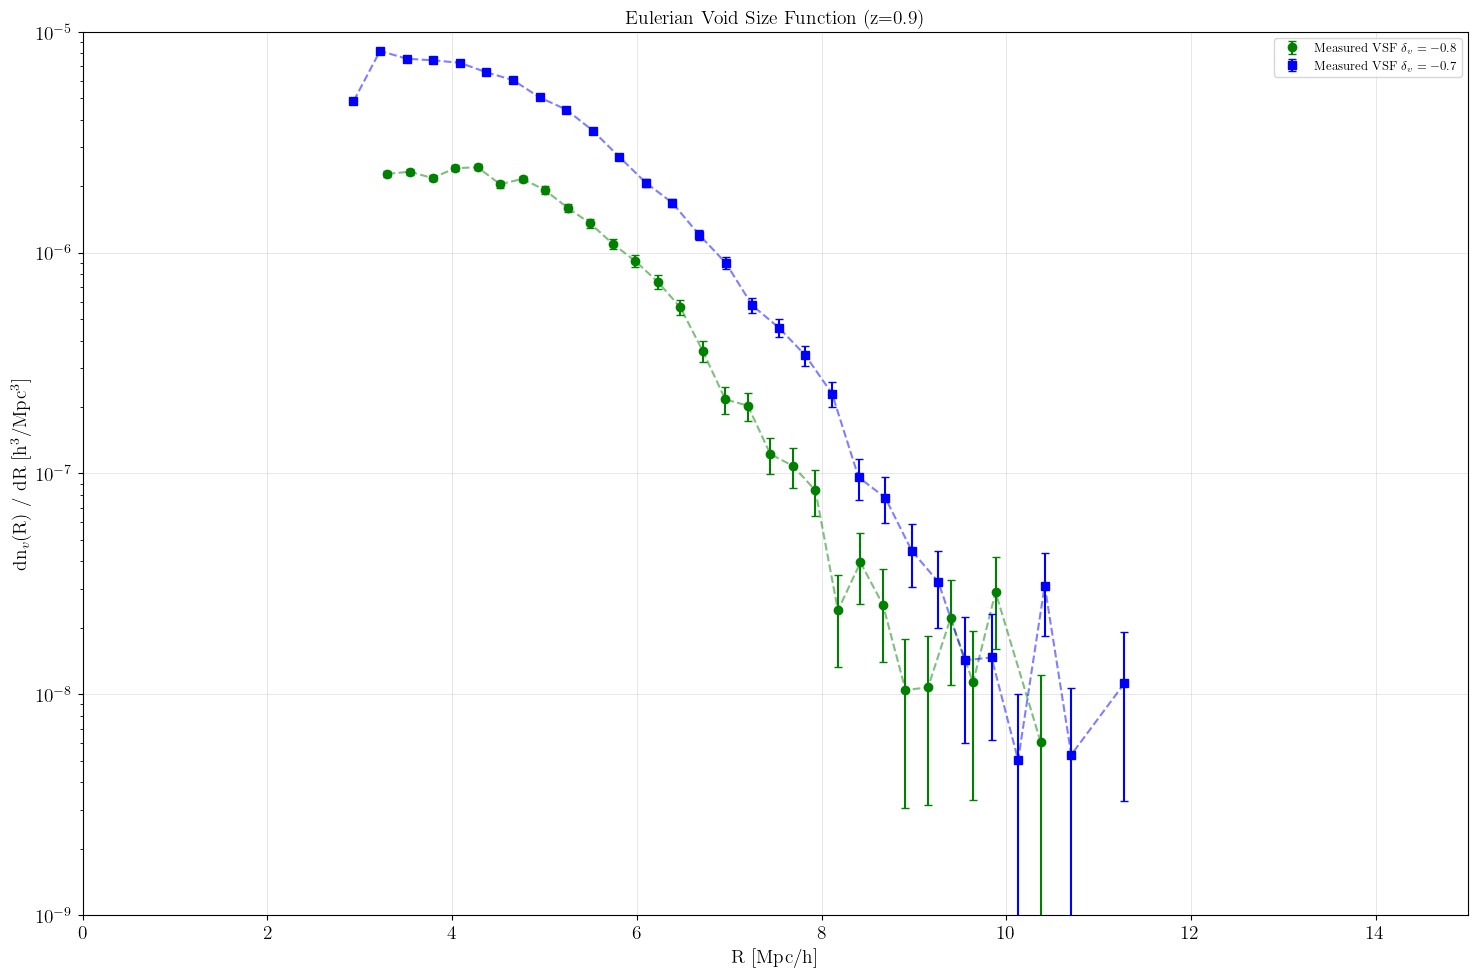

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

vsfR02 = np.array([10.37240532,  9.88466738,  9.64079841,  9.39692944,  9.15306047,
   8.9091915,  8.66532253,  8.42145356,  8.17758459,  7.93371562,
   7.68984665,  7.44597768,  7.20210872,  6.95823975,  6.71437078,
   6.47050181,  6.22663284,  5.98276387,  5.7388949,  5.49502593,
   5.25115696,  5.00728799,  4.76341902,  4.51955005,
   4.27568108,  4.03181211,  3.78794314,  3.54407418,  3.30020521])
vsf_values02 = np.array([6.08775792e-09, 2.90074772e-08, 1.13167284e-08, 2.20609318e-08,
  1.07442034e-08, 1.04579409e-08, 2.54291962e-08, 3.95416639e-08,
  2.39978837e-08, 8.38160191e-08, 1.08319542e-07, 1.22365125e-07,
  2.02898486e-07, 2.16447789e-07, 3.58611826e-07, 5.65851051e-07,
  7.38214417e-07, 9.16474245e-07, 1.09805417e-06, 1.35778103e-06,
  1.59647696e-06, 1.91908251e-06, 2.15831079e-06, 2.04250826e-06,
  2.43670206e-06, 2.41367256e-06, 2.17652690e-06, 2.32553297e-06,
  2.27591850e-06])
vsf_error02 = np.array([6.08775792e-09, 1.29725382e-08, 8.00213539e-09, 1.10304659e-08,
  7.59729910e-09, 7.39488096e-09, 1.13722822e-08, 1.39800893e-08,
  1.07321799e-08, 1.97556252e-08, 2.21106340e-08, 2.31248349e-08,
  2.92858738e-08, 2.97313903e-08, 3.75927340e-08, 4.63563243e-08,
  5.19405851e-08, 5.67283316e-08, 6.08155959e-08, 6.61741984e-08,
  7.01451705e-08, 7.50995019e-08, 7.76793052e-08, 7.36068883e-08,
  7.81974903e-08, 7.55750193e-08, 6.95621014e-08, 6.95507151e-08,
  6.63953667e-08])

vsfR03 = np.array([11.28019087, 10.70445237, 10.41658311, 10.12871386,  9.84084461,  9.55297535,
  9.2651061,   8.97723685,  8.68936759,  8.40149834,  8.11362909,  7.82575983,
  7.53789058,  7.25002133,  6.96215207,  6.67428282,  6.38641357,  6.09854431,
  5.81067506,  5.52280581,  5.23493655,  4.9470673,   4.65919805,  4.37132879,
  4.08345954,  3.79559029,  3.50772103,  3.21985178,  2.93198253])
                  
vsf_values03 = np.array([1.12227381e-08, 5.32496598e-09, 3.10905867e-08, 5.03856291e-09,
  1.46860841e-08, 1.42564795e-08, 3.22627082e-08, 4.46575679e-08,
  7.78059946e-08, 9.61251356e-08, 2.30060675e-07, 3.42579658e-07,
  4.57469393e-07, 5.77047615e-07, 9.00469976e-07, 1.20521246e-06,
  1.68060284e-06, 2.07204542e-06, 2.71421700e-06, 3.57153992e-06,
  4.45046991e-06, 5.04983931e-06, 6.04928522e-06, 6.56056386e-06,
  7.24575674e-06, 7.42978843e-06, 7.55728175e-06, 8.20243957e-06,
  4.84084318e-06])
vsf_error03 = np.array([7.93567420e-09, 5.32496598e-09, 1.26926789e-08, 5.03856291e-09,
  8.47901463e-09, 8.23098231e-09, 1.21941575e-08, 1.41219629e-08,
  1.83390488e-08, 2.00434763e-08, 3.04722808e-08, 3.65191142e-08,
  4.14173328e-08, 4.56196195e-08, 5.58447772e-08, 6.32572491e-08,
  7.30696889e-08, 7.92846145e-08, 8.85751241e-08, 9.90566947e-08,
  1.07655157e-07, 1.11477926e-07, 1.18408753e-07, 1.19441022e-07,
  1.21319942e-07, 1.18441549e-07, 1.14834272e-07, 1.14621385e-07,
  8.40267154e-08])


ax.errorbar(vsfR02, vsf_values02, yerr=vsf_error02, label=fr'Measured VSF $\delta_v = -0.8$', 
        color='green', marker='o', linestyle='None', capsize=3, markersize=6)
ax.plot(vsfR02, vsf_values02, color='green', linestyle='--', alpha=0.5)

ax.errorbar(vsfR03, vsf_values03, yerr=vsf_error03, label=fr'Measured VSF $\delta_v = -0.7$',
        color='blue', marker='s', linestyle='None', capsize=3, markersize=6)
ax.plot(vsfR03, vsf_values03, color='blue', linestyle='--', alpha=0.5)


ax.set_yscale('log')
ax.set_xlabel(r'R [Mpc/h]', fontsize=14)
ax.set_ylabel(r'dn$_v$(R) / dR [h$^3$/Mpc$^3$]', fontsize=14)
ax.set_xlim(0, 15)
ax.set_ylim(1e-9, 1e-5)
ax.grid(visible=True, which='major', axis='both', linestyle='-', linewidth=0.7, alpha=0.3)
ax.legend(fontsize=9, loc='best')
ax.set_title(f'Eulerian Void Size Function (z={z_mean:.1f})', fontsize=14)
plt.tight_layout()
plt.show()
